# Лабораторная работа №1. Разведочный анализ данных (EDA) и визуализация

**Датасет:** Wine recognition dataset (Scikit-learn)

**Курс:** Технологии машинного обучения

**Задание:** выбрать датасет без пропусков, описать его, изучить основные характеристики, провести визуальное исследование и проанализировать корреляции признаков.


## 1. Текстовое описание набора данных

Используется встроенный в Scikit-learn датасет **Wine recognition dataset** (`sklearn.datasets.load_wine`).

Это результаты химического анализа вин, выращенных в одном регионе Италии, но полученных из трёх разных сортов винограда (культиваров). Для каждого образца вина измерено 13 количественных характеристик, полученных методом химического анализа (содержание алкоголя, яблочной кислоты, золы, магния, фенолов и т.д.).

**Задача**, для которой обычно используется датасет — классификация: по химическому составу определить, к какому из трёх сортов винограда (`class_0`, `class_1`, `class_2`) относится вино.

Датасет выбран, поскольку:
- не содержит пропущенных значений (что рекомендовано для первой лабораторной работы);
- все признаки количественные, что удобно для изучения корреляций;
- имеет разумный размер (178 наблюдений × 13 признаков) — не перегружает визуализацию;
- есть целевая переменная (класс вина), что позволяет исследовать различия между группами.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

wine = load_wine(as_frame=True)
df = wine.frame.copy()
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Основные характеристики датасета

Рассмотрим размер таблицы, типы признаков, наличие пропусков и базовую описательную статистику.


In [2]:
print(f"Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов")
print()
print("Информация о столбцах:")
df.info()


Размер датасета: 178 наблюдений, 15 столбцов

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64


In [3]:
# Проверка пропущенных значений
missing = df.isna().sum()
print("Пропущенные значения по столбцам:")
print(missing)
print()
print(f"Всего пропусков в датасете: {missing.sum()}")


Пропущенные значения по столбцам:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Всего пропусков в датасете: 0


In [4]:
# Распределение по классам (сортам вина)
class_counts = df["target_name"].value_counts()
print("Распределение наблюдений по классам:")
print(class_counts)


Распределение наблюдений по классам:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [5]:
# Описательная статистика по числовым признакам
df.drop(columns=["target"]).describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Краткие выводы по характеристикам:**
- Датасет полностью без пропусков (0 пропущенных значений во всех 14 столбцах).
- 178 наблюдений, 13 количественных признаков + целевая переменная `target` (3 класса).
- Классы не идеально сбалансированы: `class_1` — 71 образец, `class_0` — 59, `class_2` — 48.
- Признаки имеют очень разный масштаб (например, `proline` — сотни единиц, `hue` — доли единицы), что важно учитывать при дальнейшем моделировании (потребуется масштабирование).


## 3. Визуальное исследование датасета

### 3.1. Распределение классов


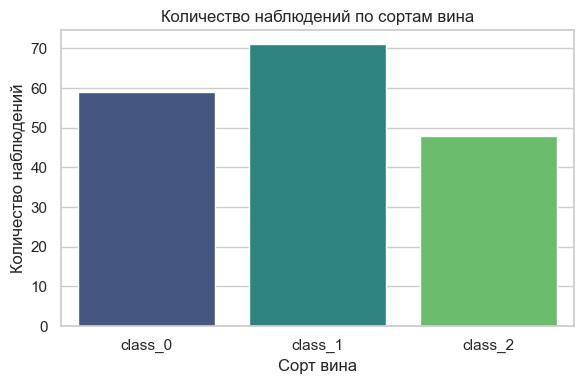

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="target_name", hue="target_name", palette="viridis", legend=False, ax=ax)
ax.set_title("Количество наблюдений по сортам вина")
ax.set_xlabel("Сорт вина")
ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()


### 3.2. Распределения отдельных признаков (гистограммы)

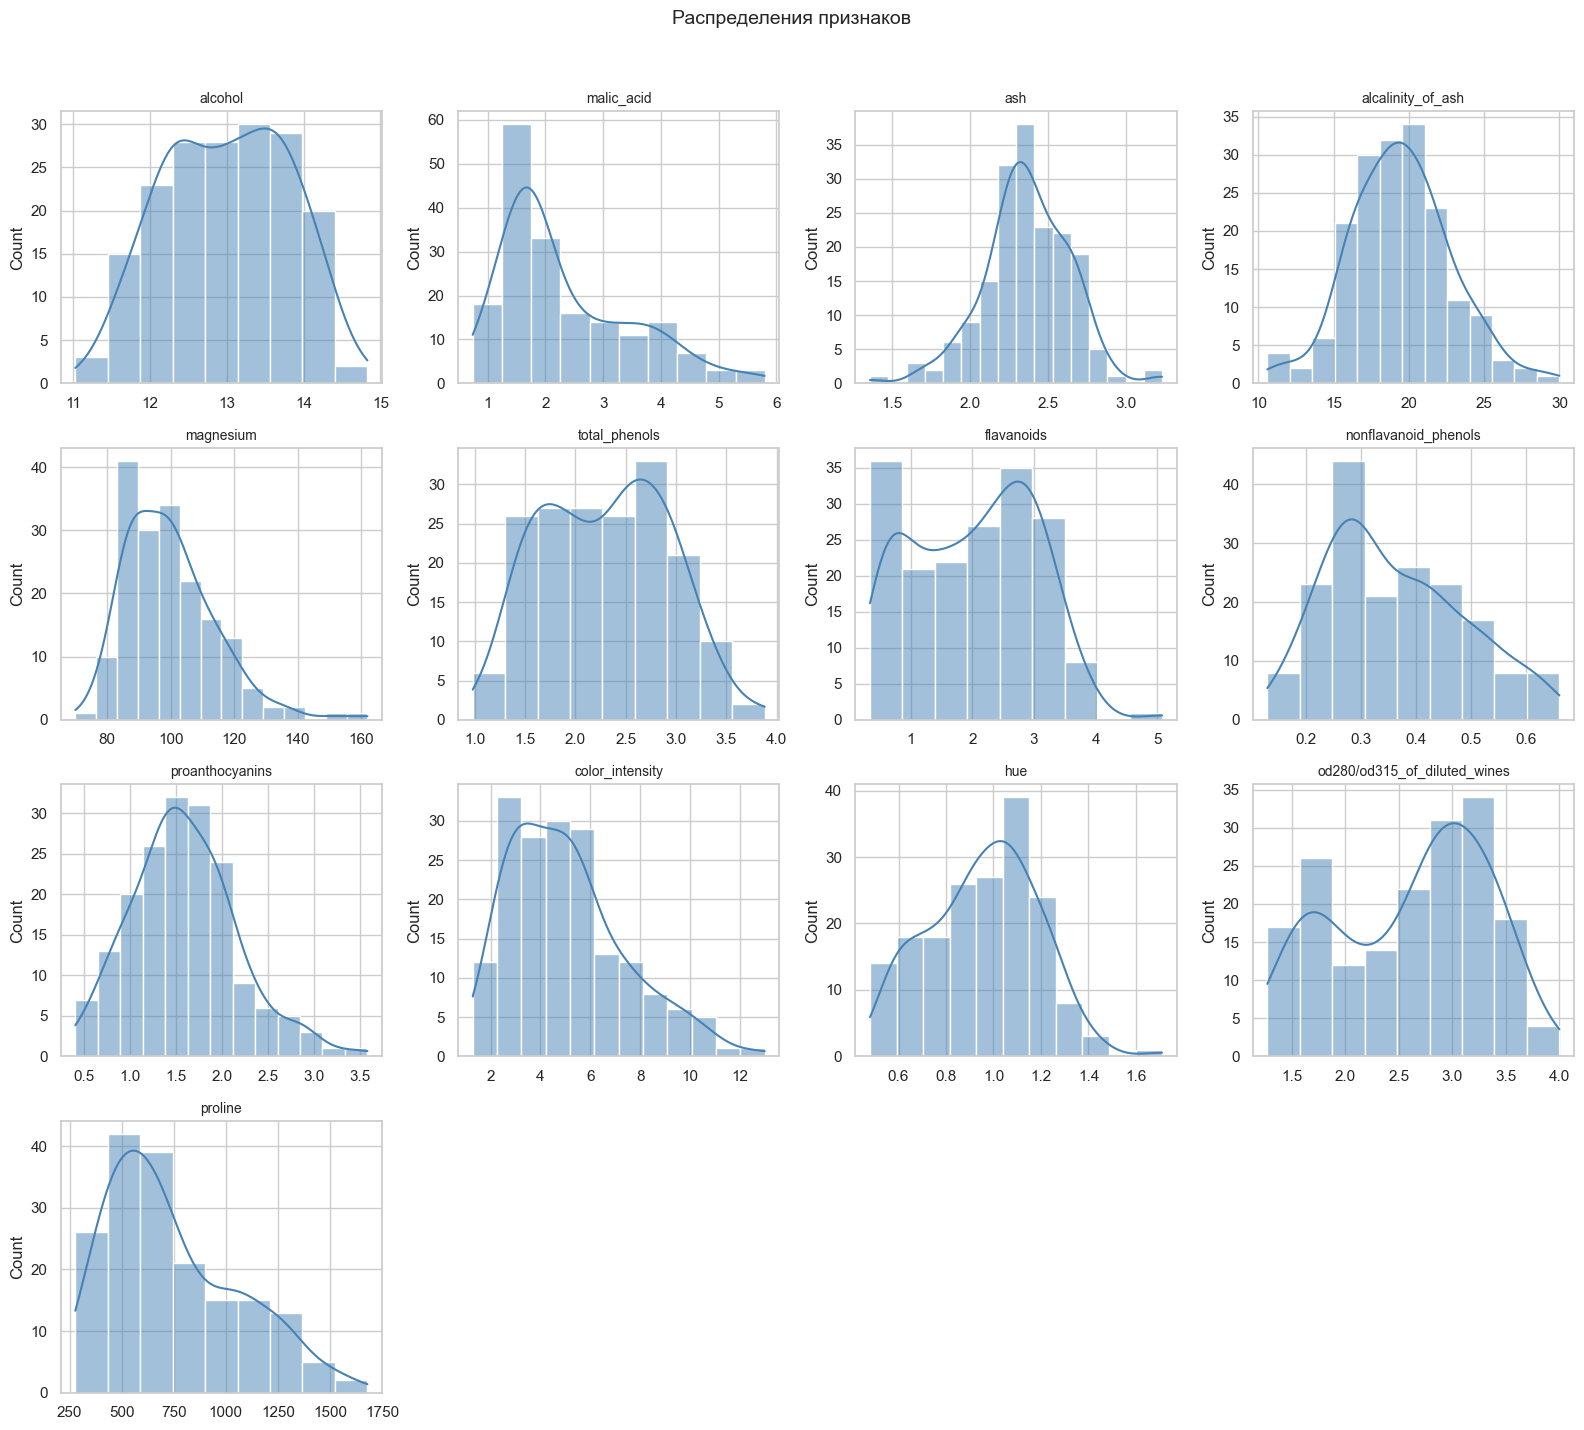

In [7]:
features = wine.feature_names
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения признаков", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3.3. Boxplot ключевых признаков по классам

Посмотрим, как различаются классы вин по нескольким наиболее интерпретируемым признакам.

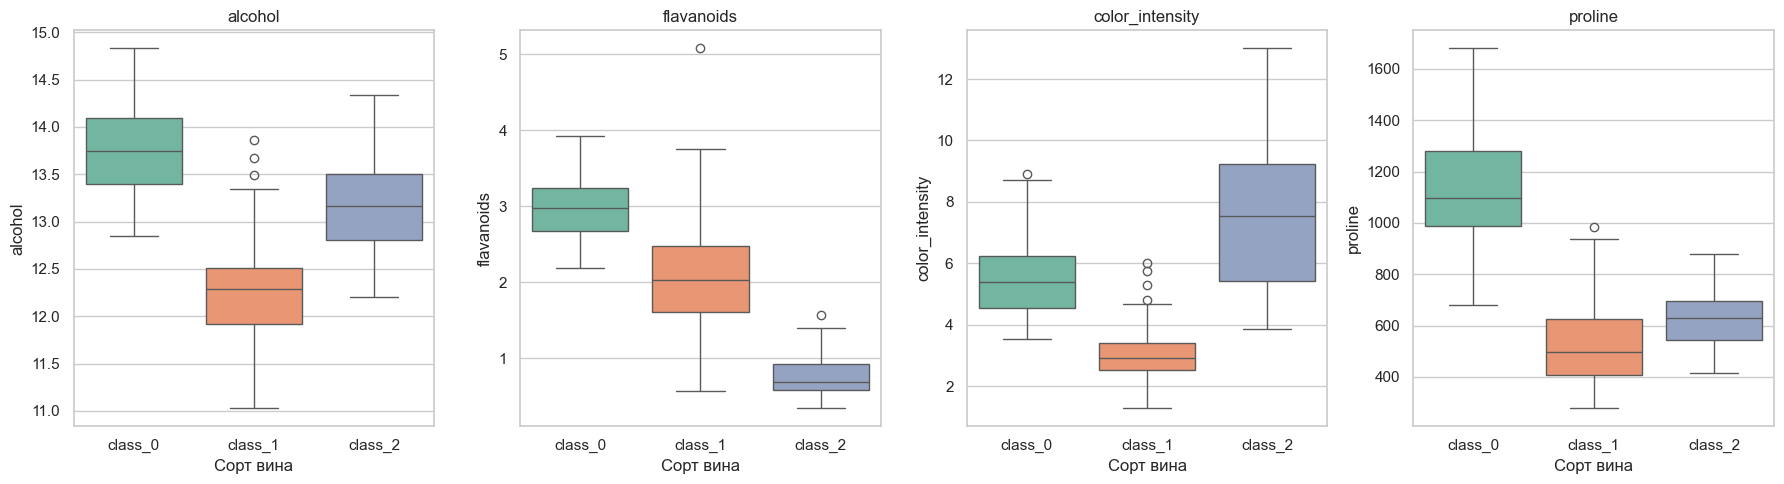

In [8]:
key_features = ["alcohol", "flavanoids", "color_intensity", "proline"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feature in zip(axes, key_features):
    sns.boxplot(data=df, x="target_name", y=feature, hue="target_name", palette="Set2", legend=False, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Сорт вина")

plt.tight_layout()
plt.show()


По этим графикам уже видно, что признаки `flavanoids`, `color_intensity` и `proline` заметно различаются между классами — они потенциально наиболее информативны для классификации сортов вина.

### 3.4. Попарные диаграммы рассеяния (pairplot) для ключевых признаков

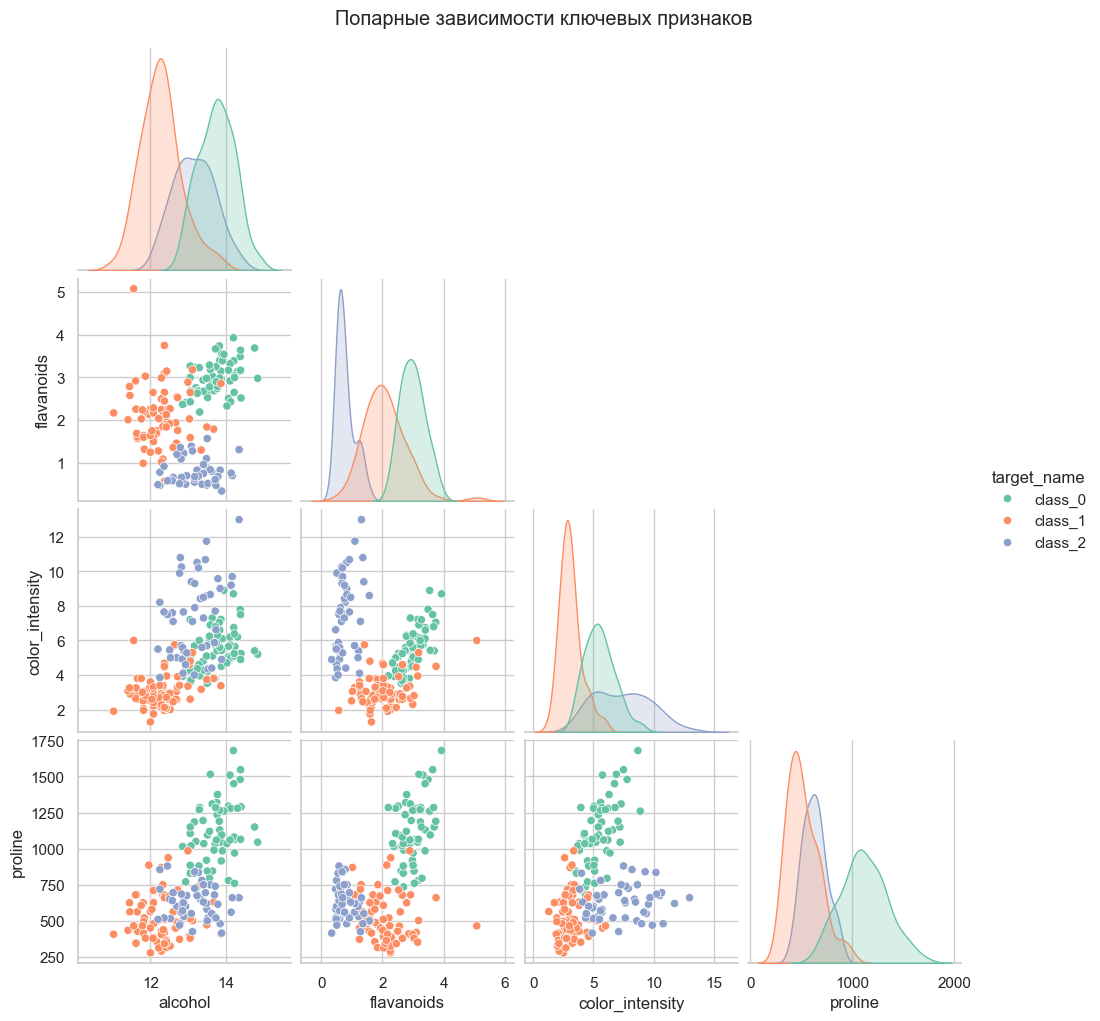

In [9]:
subset_features = ["alcohol", "flavanoids", "color_intensity", "proline", "target_name"]
sns.pairplot(df[subset_features], hue="target_name", palette="Set2", diag_kind="kde", corner=True)
plt.suptitle("Попарные зависимости ключевых признаков", y=1.02)
plt.show()


Видно, что классы довольно неплохо разделяются уже по паре признаков (`flavanoids` и `proline` в частности), что подтверждает потенциальную пригодность датасета для задачи классификации.

## 4. Информация о корреляции признаков

Так как все признаки количественные, посчитаем матрицу корреляции Пирсона и визуализируем её тепловой картой.


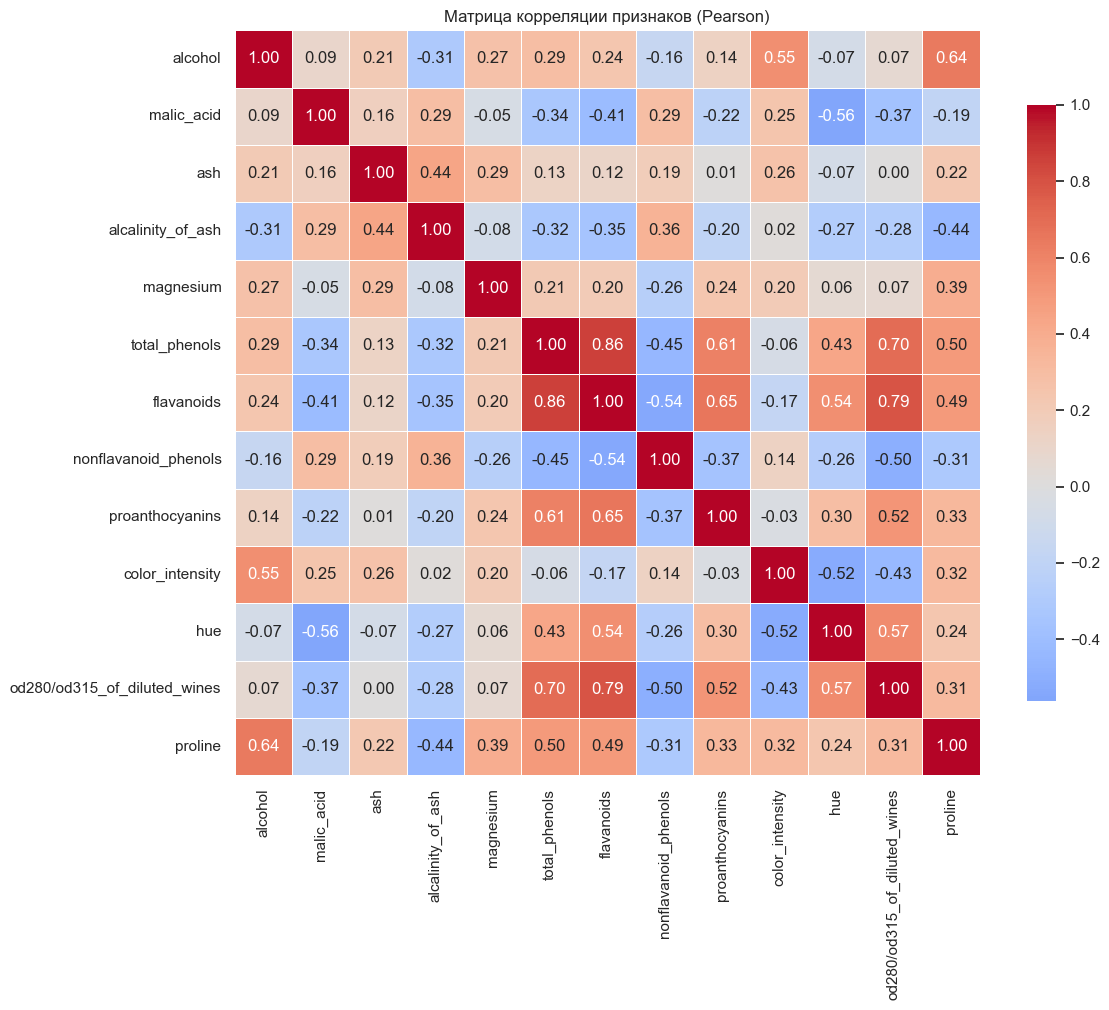

In [10]:
corr = df[wine.feature_names].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Матрица корреляции признаков (Pearson)")
plt.tight_layout()
plt.show()


In [11]:
# Топ-10 самых сильных попарных корреляций (по модулю), исключая диагональ
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_corr = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index).head(10)
top_corr.to_frame("correlation")


,,correlation
total_phenols,flavanoids,0.864564
flavanoids,od280/od315_of_diluted_wines,0.787194
total_phenols,od280/od315_of_diluted_wines,0.699949
flavanoids,proanthocyanins,0.652692
alcohol,proline,0.643720
total_phenols,proanthocyanins,0.612413
hue,od280/od315_of_diluted_wines,0.565468
malic_acid,hue,-0.561296
alcohol,color_intensity,0.546364
flavanoids,hue,0.543479


**Наблюдения по корреляциям:**

- Наиболее сильная положительная связь — между `flavanoids` и `total_phenols` (это ожидаемо: флавоноиды — основная группа фенольных соединений в вине).
- `flavanoids` также сильно коррелирует с `od280/od315_of_diluted_wines` (показатель, связанный с оптической плотностью, часто используется как косвенная мера концентрации фенолов).
- `hue` имеет заметную отрицательную корреляцию с `color_intensity` — чем интенсивнее цвет, тем ниже оттеночный показатель.
- Признак `proline` слабо коррелирует с большинством остальных признаков, что делает его независимым источником информации — это согласуется с его высокой различающей способностью между классами, увиденной на boxplot.
- Признаки `alcohol` и `color_intensity` также умеренно положительно связаны.

Такая структура корреляций полезна для дальнейшего отбора признаков: сильно скоррелированные пары (`flavanoids`/`total_phenols`, `flavanoids`/`od280_od315`) несут во многом дублирующую информацию, тогда как `proline` и `alcohol` добавляют независимую информацию.


## Итоговые выводы

1. Датасет Wine recognition из Scikit-learn содержит 178 наблюдений, 13 количественных признаков без пропусков и целевую переменную с 3 классами.
2. Классы сортов вина не идеально сбалансированы (48–71 наблюдение на класс), что стоит учитывать при построении моделей классификации.
3. Признаки имеют разные масштабы измерения — для моделирования потребуется стандартизация/нормализация.
4. Визуальный анализ (гистограммы, boxplot, pairplot) показал, что признаки `flavanoids`, `color_intensity`, `proline` хорошо разделяют классы вин.
5. Анализ корреляций выявил сильные связи между фенольными показателями (`flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines`) и относительную независимость признака `proline`, который при этом является одним из наиболее информативных для различения классов.
